<a href="https://colab.research.google.com/github/istanranjith175b-commits/Exploring-datasets/blob/main/Exp_6%2001.09.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ==============================================
# EXP_6: MNIST - PCA, t-SNE, and Digit Recognition
# ==============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ---------------------------------------------
# PART A: Data Understanding and Preprocessing
# ---------------------------------------------

# 1. Load MNIST dataset (OpenML)
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist['data'], mnist['target'].astype(int)

# For faster experimentation, use a subset (optional)
X, y = X[:10000], y[:10000]



In [3]:
# 2. Display dataset info
print("Number of samples:", X.shape[0])
print("Number of classes:", len(np.unique(y)))
print("Image dimensions: 28x28 (Flattened to", X.shape[1], "features)")



Number of samples: 10000
Number of classes: 10
Image dimensions: 28x28 (Flattened to 784 features)


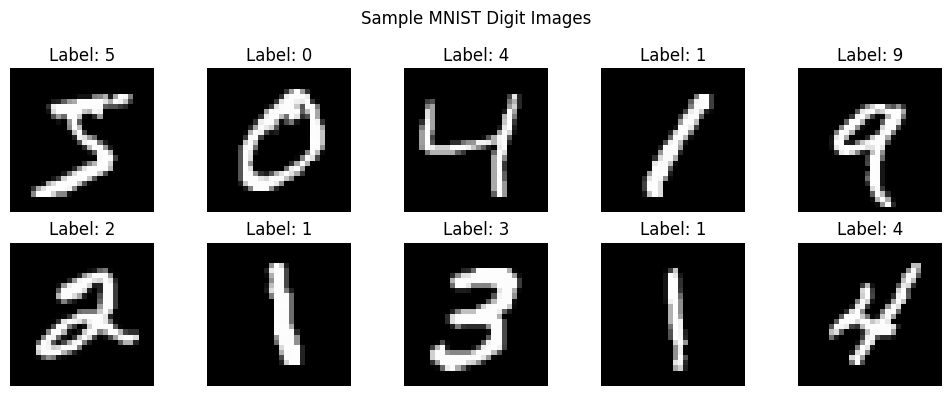

In [6]:
# 3. Visualize 10 sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.suptitle("Sample MNIST Digit Images")
plt.tight_layout()
plt.show()



In [7]:
# 4. Normalize pixel values to [0,1]
X_norm = X / 255.0



In [8]:
# ---------------------------------------------
# PART B: Principal Component Analysis (PCA)
# ---------------------------------------------

# 1. Apply PCA (full components first to study variance)
pca_full = PCA()
pca_full.fit(X_norm)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)



In [9]:
# 2. Number of components for 90%, 95%, 99% variance
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")



Components for 90% variance: 85
Components for 95% variance: 150
Components for 99% variance: 326


In [10]:
# 3. Reduce dataset to 2D and 50D
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_norm)

pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X_norm)



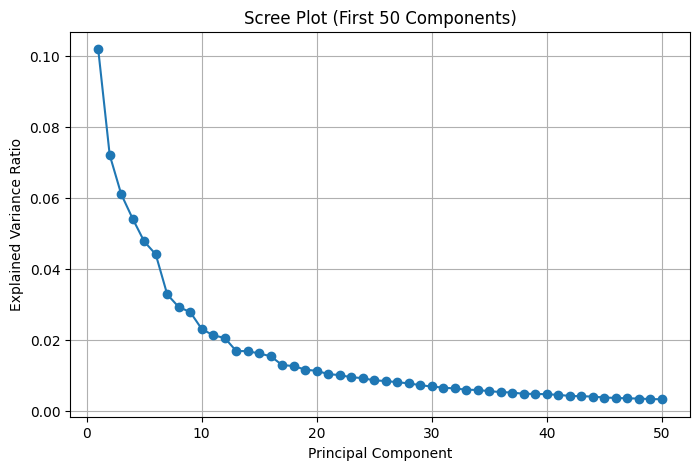

In [11]:
# 4. Plots

# Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), explained_variance[:50], marker='o')
plt.title("Scree Plot (First 50 Components)")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()



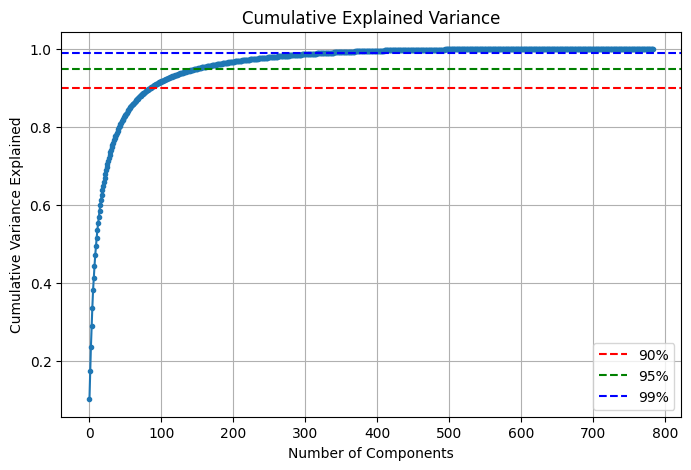

In [12]:
# Cumulative Explained Variance Plot
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='.')
plt.axhline(y=0.90, color='r', linestyle='--', label='90%')
plt.axhline(y=0.95, color='g', linestyle='--', label='95%')
plt.axhline(y=0.99, color='b', linestyle='--', label='99%')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.legend()
plt.grid(True)
plt.show()



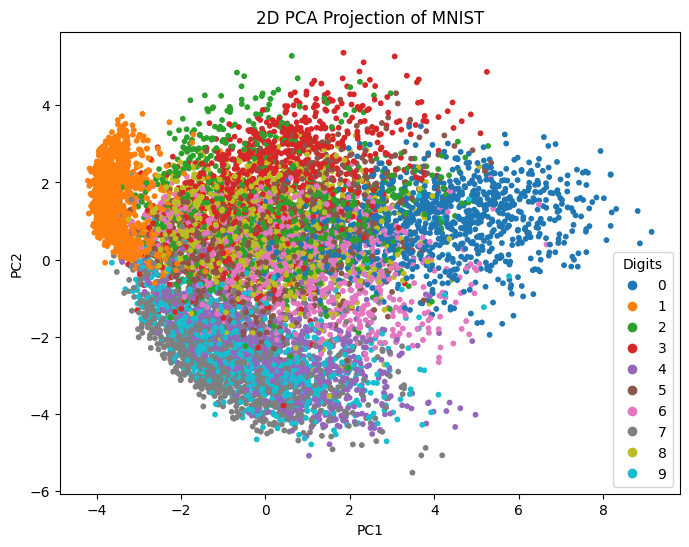

In [13]:
# 2D PCA Projection
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap='tab10', s=10)
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title("2D PCA Projection of MNIST")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



In [14]:
# ---------------------------------------------
# PART C: t-SNE Visualization
# ---------------------------------------------

# Use a smaller subset for t-SNE (to keep computation fast)
X_tsne_subset = X_norm[:3000]
y_tsne_subset = y[:3000]
X_pca50_subset = X_pca_50[:3000]



In [15]:
# 1. t-SNE on original data
tsne_orig = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_orig = tsne_orig.fit_transform(X_tsne_subset)



In [26]:
# t-SNE on PCA-reduced (50D) data
tsne_pca = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_pca = tsne_pca.fit_transform(X_pca50_subset)



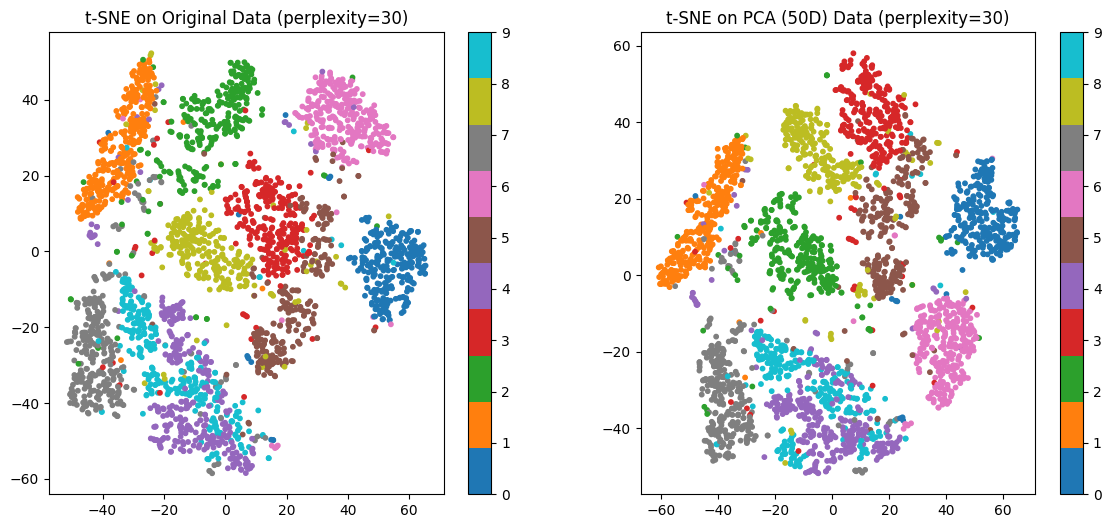

In [17]:
# 2. Plot both visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_tsne_orig[:, 0], X_tsne_orig[:, 1], c=y_tsne_subset, cmap='tab10', s=10)
axes[0].set_title("t-SNE on Original Data (perplexity=30)")
fig.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], c=y_tsne_subset, cmap='tab10', s=10)
axes[1].set_title("t-SNE on PCA (50D) Data (perplexity=30)")
fig.colorbar(sc2, ax=axes[1])

plt.show()



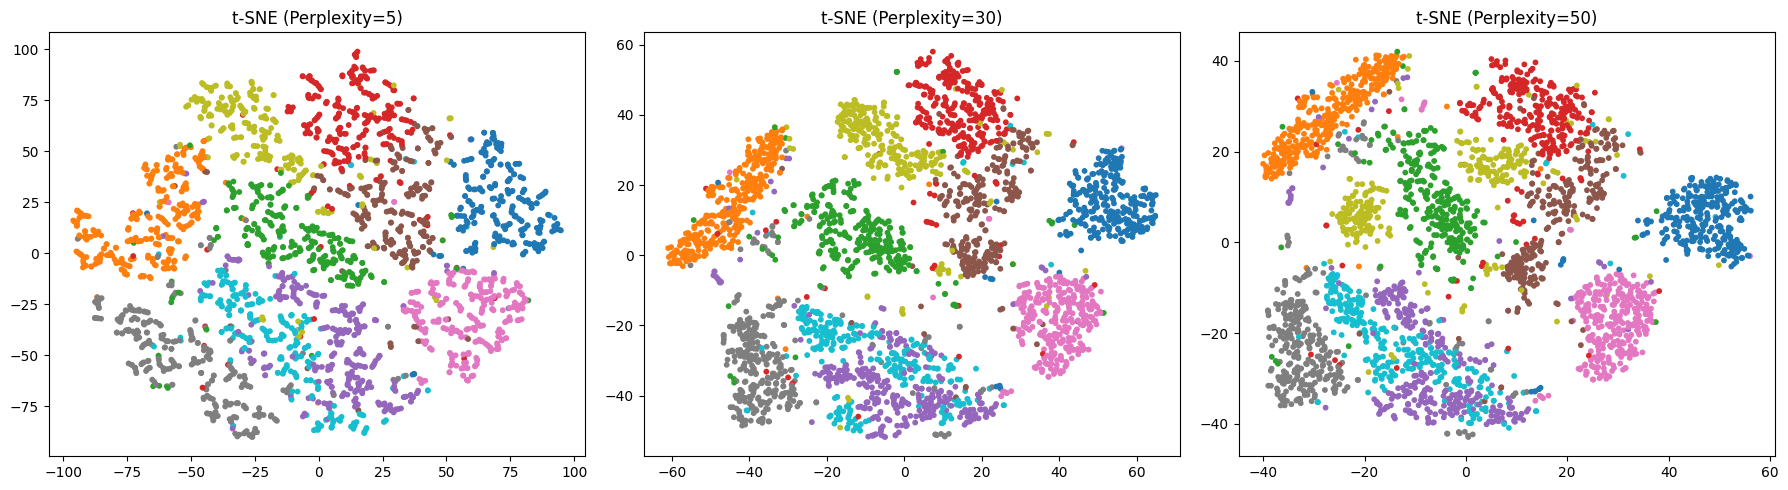

In [19]:
# 3. Experiment with different perplexity values
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 5))

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_embedded = tsne.fit_transform(X_pca50_subset)
    axes[i].scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_tsne_subset, cmap='tab10', s=10)
    axes[i].set_title(f"t-SNE (Perplexity={p})")

plt.tight_layout()
plt.show()



In [20]:
# ---------------------------------------------
# PART D: Digit Recognition Analysis
# ---------------------------------------------

# Train-test split (original 784-dim data)
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42)

# Train-test split (PCA 50-dim data)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_50, y, test_size=0.2, random_state=42)

def evaluate_classifier(clf, X_train, X_test, y_train, y_test, name=""):
    start_train = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = clf.predict(X_test)
    pred_time = time.time() - start_pred

    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Training Time: {train_time:.4f} sec")
    print(f"Prediction Time: {pred_time:.4f} sec")

    return acc, train_time, pred_time

# KNN on Original Data
knn_orig = KNeighborsClassifier(n_neighbors=5)
evaluate_classifier(knn_orig, X_train, X_test, y_train, y_test, "KNN - Original Data (784D)")




KNN - Original Data (784D)
Accuracy: 0.9475
Training Time: 0.0064 sec
Prediction Time: 0.8865 sec


(0.9475, 0.006378889083862305, 0.8865361213684082)

In [21]:
# KNN on PCA Data
knn_pca = KNeighborsClassifier(n_neighbors=5)
evaluate_classifier(knn_pca, X_train_pca, X_test_pca, y_train_pca, y_test_pca, "KNN - PCA Data (50D)")




KNN - PCA Data (50D)
Accuracy: 0.9590
Training Time: 0.0036 sec
Prediction Time: 0.1191 sec


(0.959, 0.003618001937866211, 0.11905455589294434)

In [24]:

# SVM on Original Data (using smaller subset for speed)
svm_orig = SVC(kernel='rbf')
evaluate_classifier(svm_orig, X_train[:3000], X_test[:1000], y_train[:3000], y_test[:1000], "SVM - Original Data (784D)")


SVM - Original Data (784D)
Accuracy: 0.9470
Training Time: 1.3860 sec
Prediction Time: 1.6024 sec


(0.947, 1.3860077857971191, 1.6024081707000732)

In [25]:

# SVM on PCA Data
svm_pca = SVC(kernel='rbf')
evaluate_classifier(svm_pca, X_train_pca[:3000], X_test_pca[:1000], y_train_pca[:3000], y_test_pca[:1000], "SVM - PCA Data (50D)")


SVM - PCA Data (50D)
Accuracy: 0.9540
Training Time: 0.6796 sec
Prediction Time: 0.2102 sec


(0.954, 0.6796205043792725, 0.21019530296325684)